In [14]:
from matplotlib import pylab 
params = {'xtick.labelsize': 18, 
'ytick.labelsize': 18, 
'axes.titlesize' : 22, 
'axes.labelsize' : 20, 
'legend.fontsize': 10, 
'legend.title_fontsize': 14, 
'figure.titlesize': 24 } 
pylab.rcParams.update(params)

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
dataset = pd.read_csv('data_HW3.csv')

In [20]:
from sklearn.model_selection import train_test_split 
from prepare import prepare_data
train_set,test_set= train_test_split(dataset,test_size=0.2, random_state=108)
normalized_train_set = prepare_data(train_set,train_set)
normalized_test_set = prepare_data(train_set,test_set)


In [25]:
# part 1 Q3
from sklearn.linear_model import LinearRegression
from LinearRegressor import LinearRegressor as HuberRegressor
from sklearn.metrics import mean_squared_error

X_train, X_val, y_train, y_val = train_test_split(normalized_train_set.drop(columns='contamination_level'), normalized_train_set['contamination_level'], test_size=0.2, random_state=108)
# Fit a linear regression model to the training data
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Calculate the residuals for the regressor model
y_train_pred = regressor.predict(X_train)
residuals = np.abs(y_train_pred - y_train)

# Initialize variables for min loss and corresponding delta
min_loss = float(1e9)
best_delta = None

# For each quantile Q in the range from 80 to 95
for Q in range(80, 100):
    # Get the Qth quantile for the residuals
    delta_Q = np.quantile(residuals, Q/100)

    # Train a regressor using the Huber loss function with delta_Q
    huber_regressor = HuberRegressor(lr=0.07, huber_delta=delta_Q)
    huber_regressor.fit(X_train, y_train)

    # Evaluate the accuracy of the regressor on the validation set
    y_val_pred = huber_regressor.predict(X_val)

    #calculate MSE
    val_losses_MSE = mean_squared_error(y_val, y_val_pred)
    print(f'Quantile: {Q}, Delta: {delta_Q}, loss: {val_losses_MSE}')
    # Update best accuracy and corresponding delta if necessary
    if val_losses_MSE < min_loss:
        min_loss = val_losses_MSE
        best_delta = delta_Q

# Set delta to the value corresponding to the best accuracy obtained during validation
delta0 = best_delta
print(f'Best delta: {delta0}')


Quantile: 80, Delta: 2.0598580062223846, loss: 3.8158524702048657
Quantile: 81, Delta: 2.198436912821625, loss: 3.7903793342925964
Quantile: 82, Delta: 2.3252678996461773, loss: 3.7689042156178947
Quantile: 83, Delta: 2.3873761130565745, loss: 3.7603869316031138
Quantile: 84, Delta: 2.450019409403387, loss: 3.7522015184420967
Quantile: 85, Delta: 2.581099654197909, loss: 3.736508917218922
Quantile: 86, Delta: 2.664206521478337, loss: 3.726844281285152
Quantile: 87, Delta: 2.8056193092397397, loss: 3.711614866306279
Quantile: 88, Delta: 2.8596824743583227, loss: 3.706593685304497
Quantile: 89, Delta: 3.0369738043783387, loss: 3.6938402538355586
Quantile: 90, Delta: 3.110634457429865, loss: 3.6896989770554867
Quantile: 91, Delta: 3.1650713266391057, loss: 3.687335786074438
Quantile: 92, Delta: 3.2769005102513535, loss: 3.683882827808359
Quantile: 93, Delta: 3.4185801620796914, loss: 3.6807832594924936
Quantile: 94, Delta: 3.6798271083014074, loss: 3.6793657168520806
Quantile: 95, Delta: 

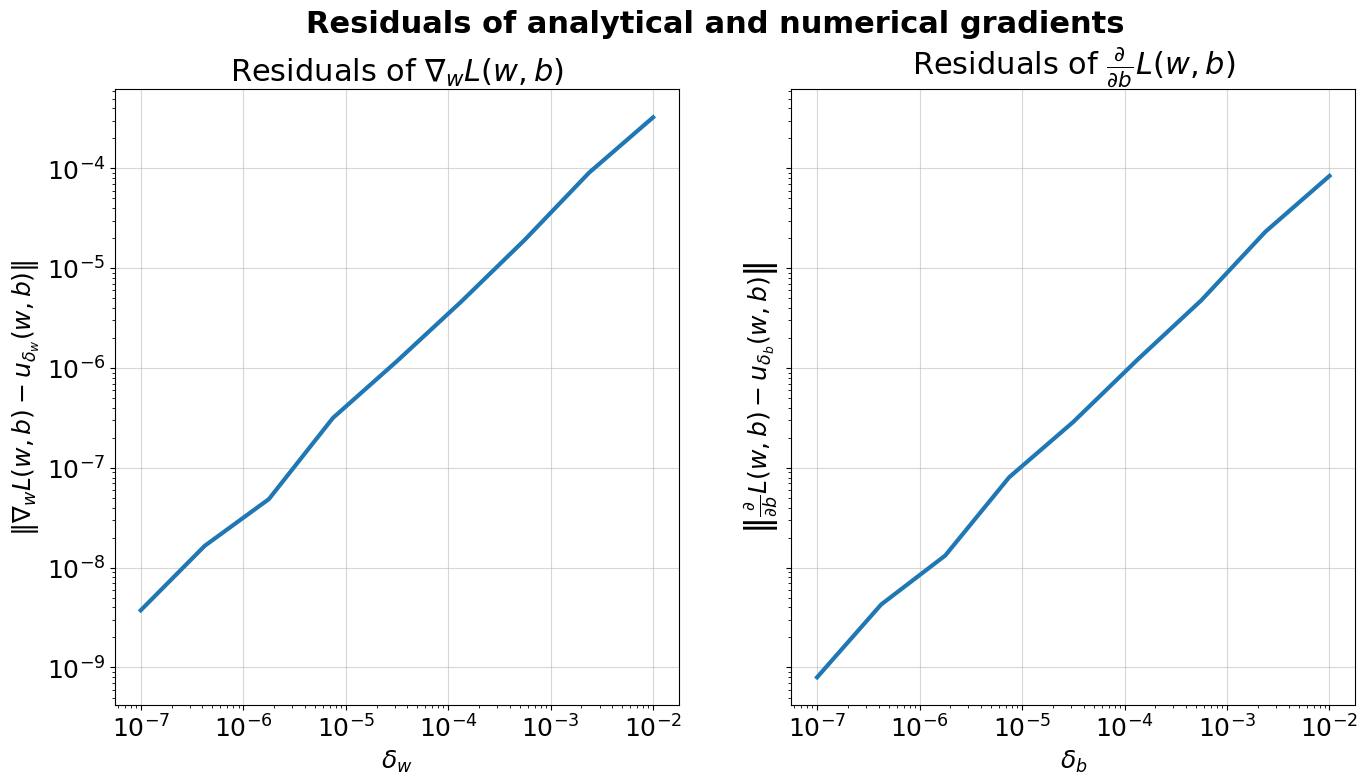

In [11]:
# part 1 Q4
from verify_gradients import compare_gradients
X_train, X_val, y_train, y_val = train_test_split(normalized_train_set.drop(columns='contamination_level'), normalized_train_set['contamination_level'], test_size=0.2, random_state=108)
huber_delta = 0.1
compare_gradients(X_train, y_train, huber_delta, deltas=np.logspace(-7, -2, 9))

lr size = 1e-09, Best train loss = 2.632264685598581, Best validation loss = 2.664685531410539
lr size = 1e-08, Best train loss = 2.632222786509684, Best validation loss = 2.6646446696721817
lr size = 1e-07, Best train loss = 2.6318039179710753, Best validation loss = 2.664236174268701
lr size = 1e-06, Best train loss = 2.62762743963718, Best validation loss = 2.660163392362872
lr size = 1e-05, Best train loss = 2.587060731639576, Best validation loss = 2.620634411263006
lr size = 0.0001, Best train loss = 2.279635052912615, Best validation loss = 2.323461527197623
lr size = 0.001, Best train loss = 1.713578920685108, Best validation loss = 1.7800055960723646
lr size = 0.01, Best train loss = 1.6517562316843981, Best validation loss = 1.7241540991826134
lr size = 0.1, Best train loss = 1.6528795787605457, Best validation loss = 1.7232561883734314


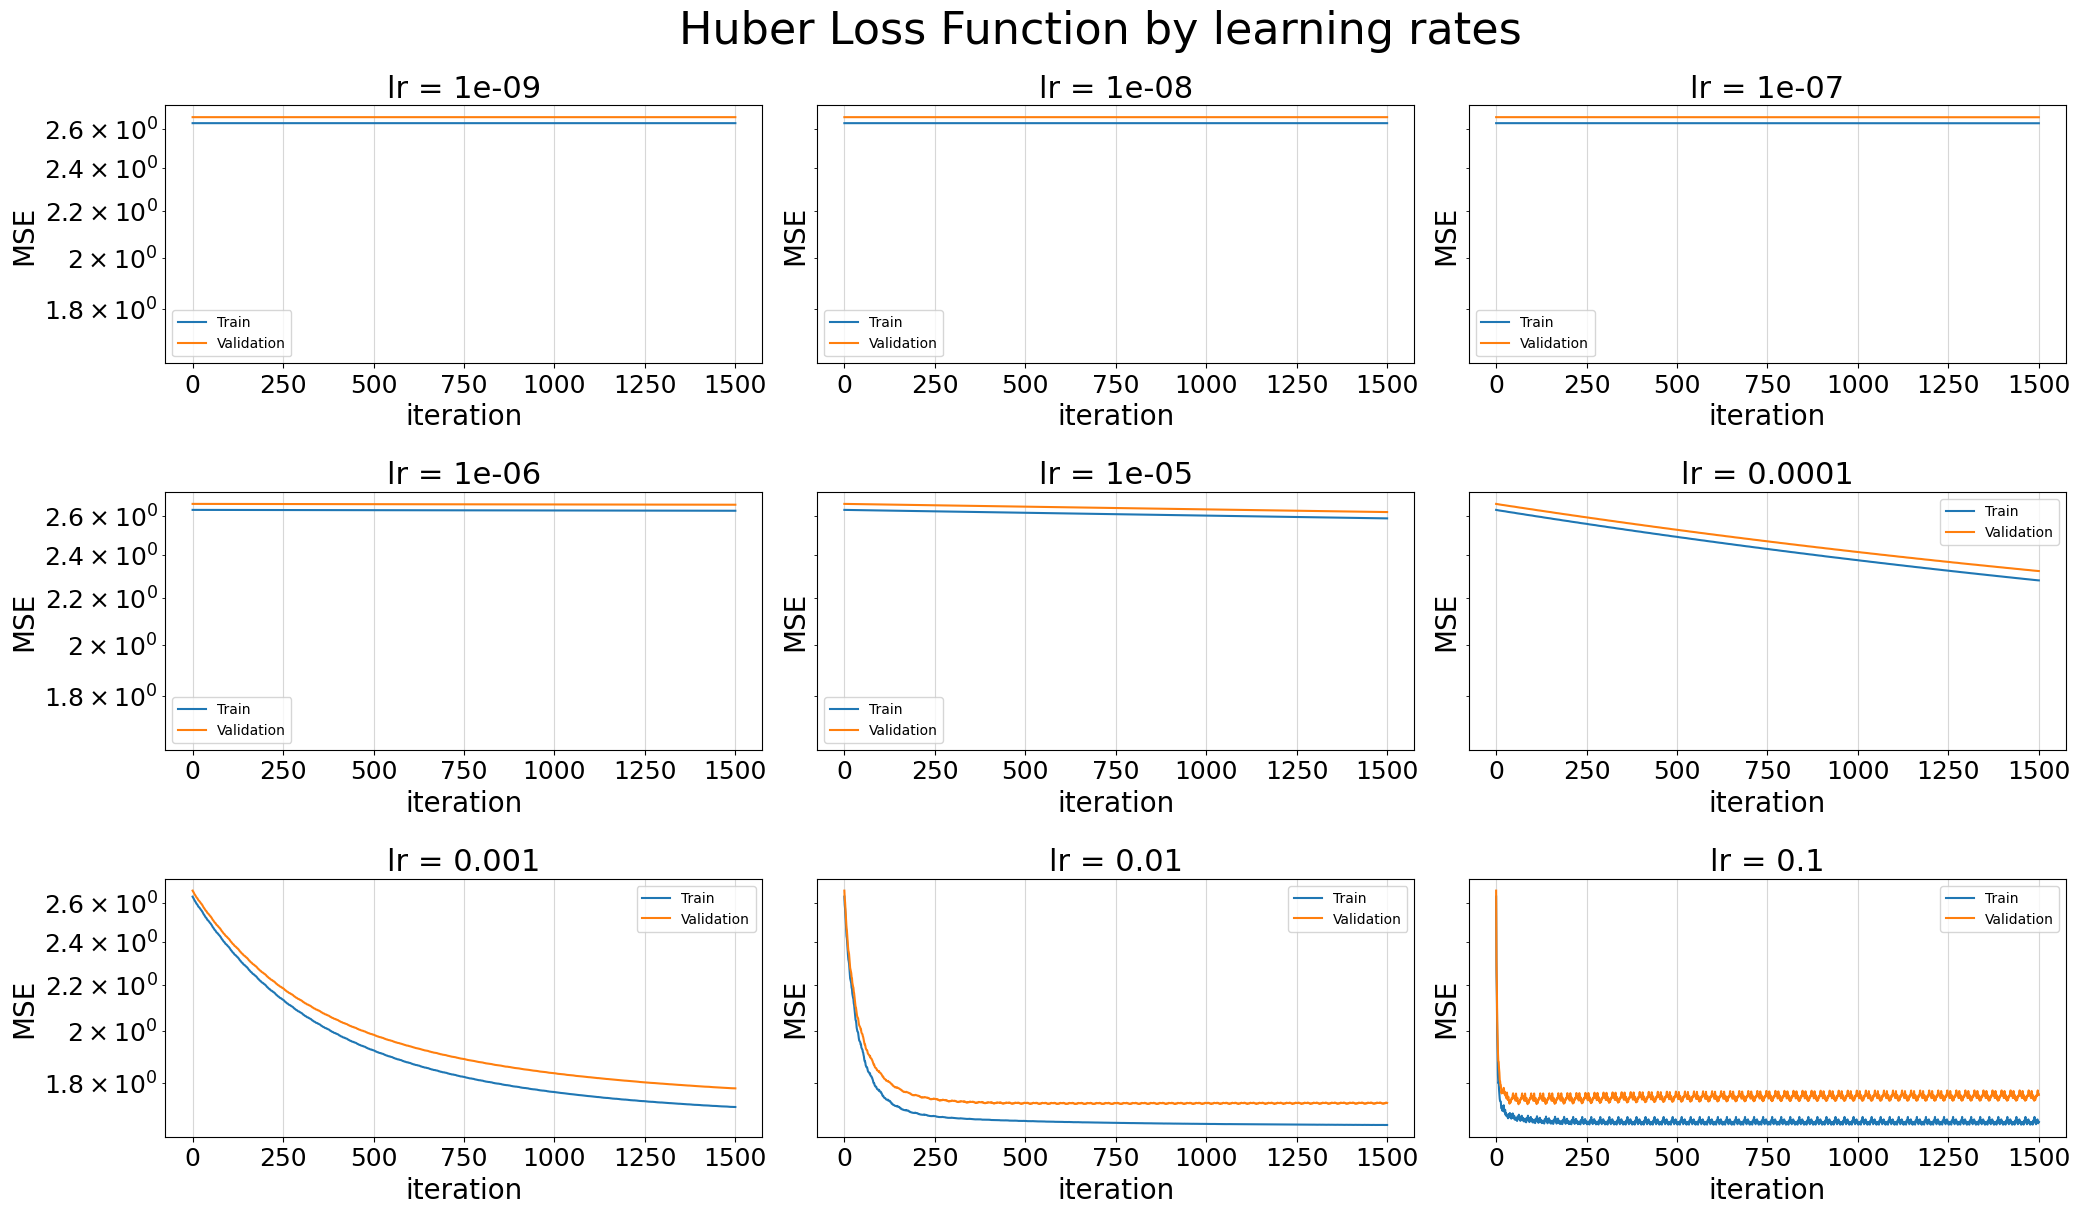

In [28]:
from test_lr import test_lr
X_train, X_val, y_train, y_val = train_test_split(normalized_train_set.drop(columns='contamination_level'), normalized_train_set['contamination_level'], test_size=0.2)
huber_delta = delta0
test_lr(X_train, y_train, X_val, y_val, huber_delta, title='Huber Loss Function by learning rates')

In [29]:
# Part 2 Q7
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, mean_squared_error

X_train = normalized_train_set.drop(columns='contamination_level')
y_train = normalized_train_set['contamination_level']
# Create a DummyRegressor
dummy_regressor = DummyRegressor()

# Perform cross-validation
cv_results = cross_validate(dummy_regressor, X_train, y_train, scoring='neg_mean_squared_error', cv=5, return_train_score=True)

# Calculate the mean squared error
mean_mse = -cv_results['test_score'].mean()
mean_mse_train = -cv_results['train_score'].mean()
# Print the mean squared error
print(f"Cross-validated MSE val: {mean_mse}")
print(f"Cross-validated MSE train: {mean_mse_train}")

dummy_regressor.fit(X_train, y_train)

Cross-validated MSE val: 5.100442366847775
Cross-validated MSE train: 5.092072995343603


DummyRegressor()

In [30]:
def huber_loss(y_true, y_pred, delta=delta0):
    residuals = np.abs(y_true - y_pred)
    mask = residuals <= delta
    loss = np.zeros_like(residuals)
    loss[mask] = 0.5 * residuals[mask] ** 2
    loss[~mask] = delta * residuals[~mask] - 0.5 * delta ** 2
    return loss.mean()

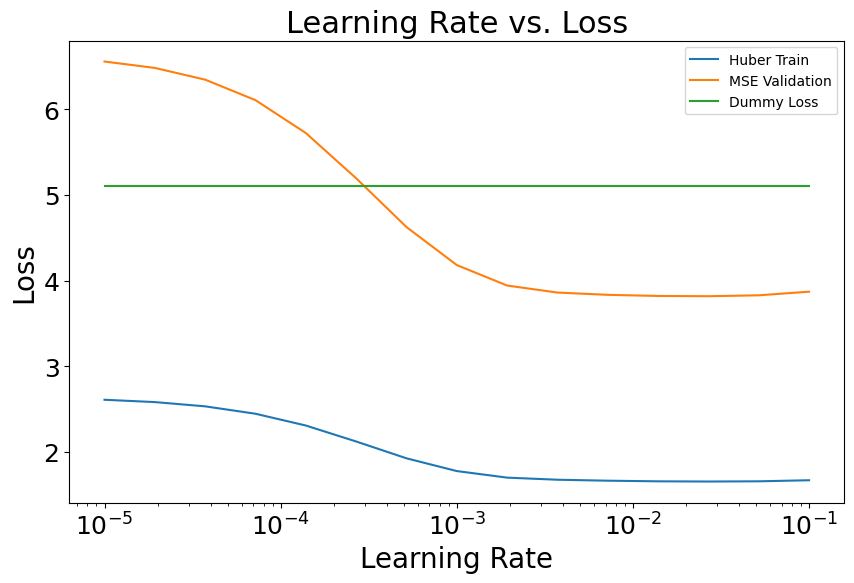

Best learning rate: 0.026826957952797246
Best Train: 1.653845242079349
Best loss: 3.8175139432645935


LinearRegressor(huber_delta=3.6798271083014074, lr=0.026826957952797246)

In [31]:
# Part 2 Q8
from numpy import logspace
from LinearRegressor import LinearRegressor as HuberRegressor
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer

X_train = normalized_train_set.drop(columns='contamination_level')
y_train = normalized_train_set['contamination_level']
# Create a HuberRegressor
huber_delta = delta0
train_losses_huber = {}
val_losses_huber = {}
huber_loss_scorer = make_scorer(huber_loss, greater_is_better=False)
for lr in logspace(-5, -1, 15):
  huberRegressor = HuberRegressor(huber_delta=huber_delta, lr=lr)
  # Perform cross-validation
  cv_results = cross_validate(huberRegressor, X_train, y_train, scoring={'huber_loss': huber_loss_scorer, 'mse': 'neg_mean_squared_error'}, cv=5, return_train_score=True)
  train_losses_huber[lr] = -cv_results['train_huber_loss'].mean()
  val_losses_huber[lr] = -cv_results['test_mse'].mean()

# Plot the learning rate vs. mean squared error
plt.figure(figsize=(10, 6))
plt.plot(list(val_losses_huber.keys()), list(train_losses_huber.values()), label='Huber Train')
plt.plot(list(val_losses_huber.keys()), list(val_losses_huber.values()), label='MSE Validation')
plt.plot(list(val_losses_huber.keys()), [mean_mse]*len(val_losses_huber.keys()), label='Dummy Loss')
plt.xscale('log')
plt.xlabel('Learning Rate')
plt.ylabel('Loss')
plt.title('Learning Rate vs. Loss')
plt.legend()
plt.show()

print(f"Best learning rate: {min(val_losses_huber, key=val_losses_huber.get)}")
print(f"Best Train: {train_losses_huber[min(train_losses_huber, key=train_losses_huber.get)]}")
print(f"Best loss: {val_losses_huber[min(val_losses_huber, key=val_losses_huber.get)]}")

huberRegressor = HuberRegressor(huber_delta=huber_delta, lr=min(val_losses_huber, key=val_losses_huber.get))
huberRegressor.fit(X_train, y_train)



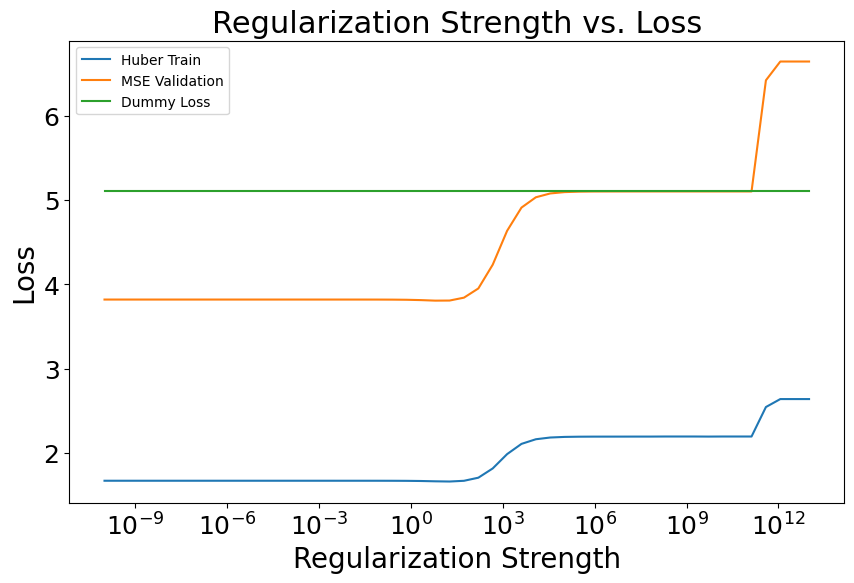

Best Regularization Strength: 6.250551925273976
Best Train: 1.6611467550347339
Best loss: 3.805866579833868


HuberRegressor(alpha=6.250551925273976, epsilon=3.6798271083014074)

In [33]:
# Part 3 Q10
from sklearn.linear_model import HuberRegressor
import matplotlib.pyplot as plt

X_train = normalized_train_set.drop(columns='contamination_level')
y_train = normalized_train_set['contamination_level']
# Define the range of regularization strengths to try
alphas = logspace(-10, 13, 50)

# Initialize lists to store the validation errors
val_errors = []

train_losses_ridge = {}
val_losses_ridge = {}

# Perform k-fold cross-validation for each alpha value
for alpha in alphas:
    ridge_regressor = HuberRegressor(epsilon=delta0, alpha=alpha, fit_intercept=True)
    cv_results = cross_validate(ridge_regressor, X_train, y_train, scoring={'huber_loss': huber_loss_scorer, 'mse': 'neg_mean_squared_error'}, cv=5, return_train_score=True)
    train_losses_ridge[alpha] = -cv_results['train_huber_loss'].mean()
    val_losses_ridge[alpha] = -cv_results['test_mse'].mean()


# Plot the learning rate vs. mean squared error
plt.figure(figsize=(10, 6))
plt.plot(list(val_losses_ridge.keys()), list(train_losses_ridge.values()), label='Huber Train')
plt.plot(list(val_losses_ridge.keys()), list(val_losses_ridge.values()), label='MSE Validation')
plt.plot(list(val_losses_ridge.keys()), [mean_mse]*len(val_losses_ridge.keys()), label='Dummy Loss')
plt.xscale('log')
plt.xlabel('Regularization Strength')
plt.ylabel('Loss')
plt.title('Regularization Strength vs. Loss')
plt.legend()
plt.show()

print(f"Best Regularization Strength: {min(val_losses_ridge, key=val_losses_ridge.get)}")
print(f"Best Train: {train_losses_ridge[min(train_losses_ridge, key=train_losses_ridge.get)]}")
print(f"Best loss: {val_losses_ridge[min(val_losses_ridge, key=val_losses_ridge.get)]}")

ridge_regressor = HuberRegressor(epsilon=delta0, alpha=min(val_losses_ridge, key=val_losses_ridge.get), fit_intercept=True)
ridge_regressor.fit(X_train, y_train)


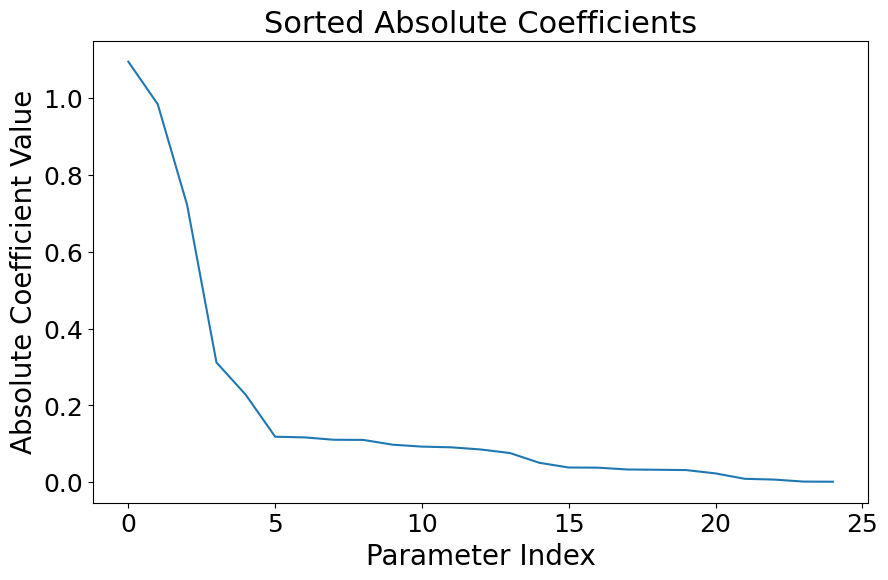

In [35]:
# Part 3 Q12
# Get the coefficients from the LinearRegression model
coefficients = ridge_regressor.coef_

# Calculate the absolute values of the coefficients
abs_coefficients = np.abs(coefficients)

# Sort the absolute values in descending order
sorted_indices = np.argsort(abs_coefficients)[::-1]
sorted_abs_coefficients = abs_coefficients[sorted_indices]

# Plot the sorted absolute values
plt.figure(figsize=(10, 6))
plt.plot(range(len(sorted_abs_coefficients)), sorted_abs_coefficients)
plt.xlabel('Parameter Index')
plt.ylabel('Absolute Coefficient Value')
plt.title('Sorted Absolute Coefficients')
plt.show()


c:\Users\t-amuslih\OneDrive - Technion\Sem 7\ML\Major HW3\plot3d.py:28: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


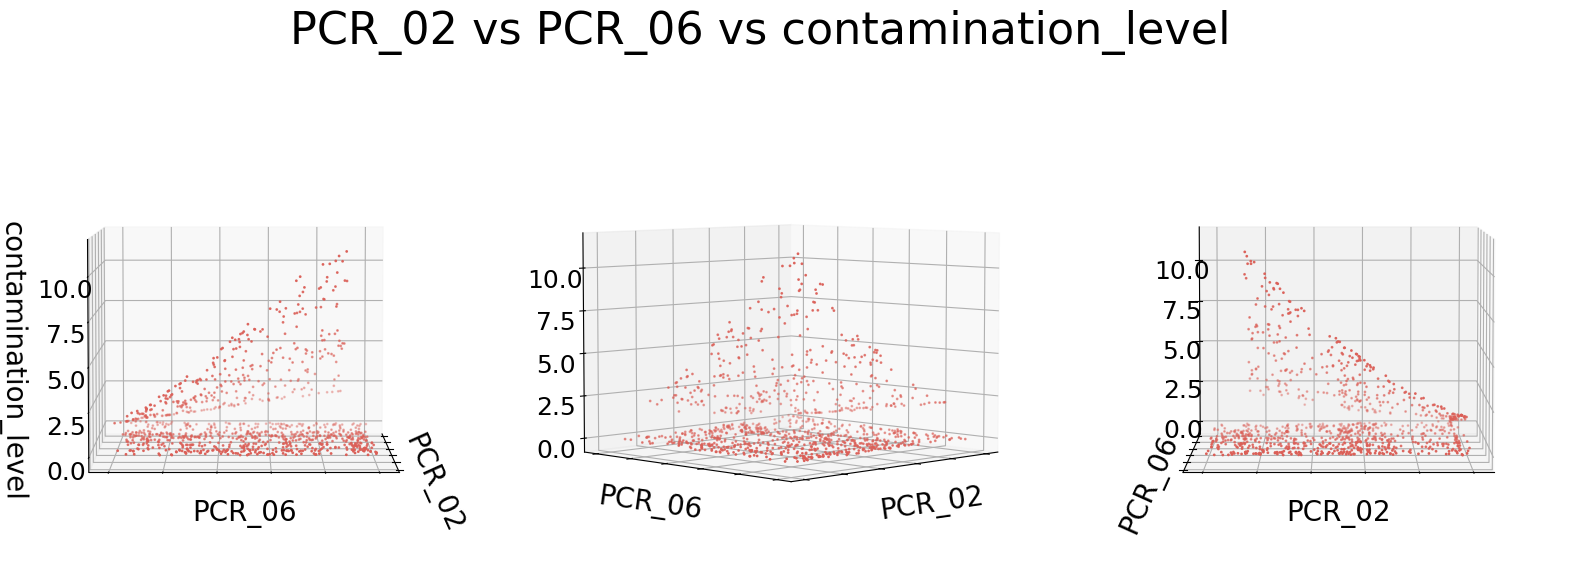

In [38]:
# Part 4 Q14
from plot3d import plot3d
plot3d(normalized_train_set, "PCR_02", "PCR_06", "contamination_level", title='PCR_02 vs PCR_06 vs contamination_level')


In [36]:
# Part 4 Q15
from sklearn.linear_model import HuberRegressor

# Create the HuberRegressor object
huber_regressor_part4 = HuberRegressor(epsilon=delta0, alpha=min(val_losses_ridge, key=val_losses_ridge.get), fit_intercept=True)

X_train = normalized_train_set[["PCR_02","PCR_06"]]
y_train = normalized_train_set['contamination_level']
# Fit the model to the training data
huber_regressor_part4.fit(X_train, y_train)


HuberRegressor(alpha=6.250551925273976, epsilon=3.6798271083014074)

c:\Users\t-amuslih\OneDrive - Technion\Sem 7\ML\Major HW3\plot3d.py:28: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


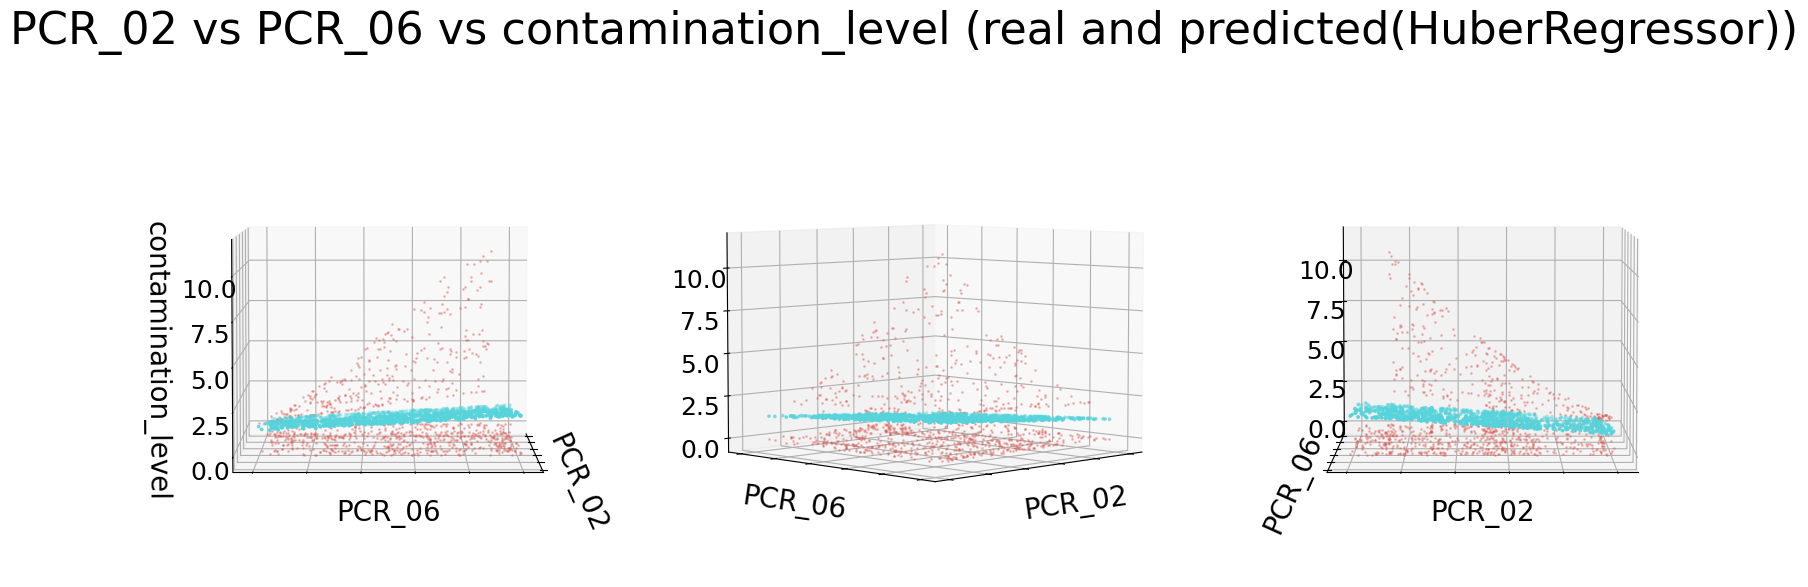

Train loss: 4.896815994990475


In [44]:
# Part 4 Q16

X_train = normalized_train_set[["PCR_02","PCR_06"]]
y_train = normalized_train_set['contamination_level']
# Plotting the predicted values
predicted_values = huber_regressor_part4.predict(X_train)

plot3d(normalized_train_set, "PCR_02", "PCR_06", "contamination_level", title='PCR_02 vs PCR_06 vs contamination_level (real and predicted(HuberRegressor))', predictions=predicted_values)
print(f"Train loss: {mean_squared_error(y_train, predicted_values)}")


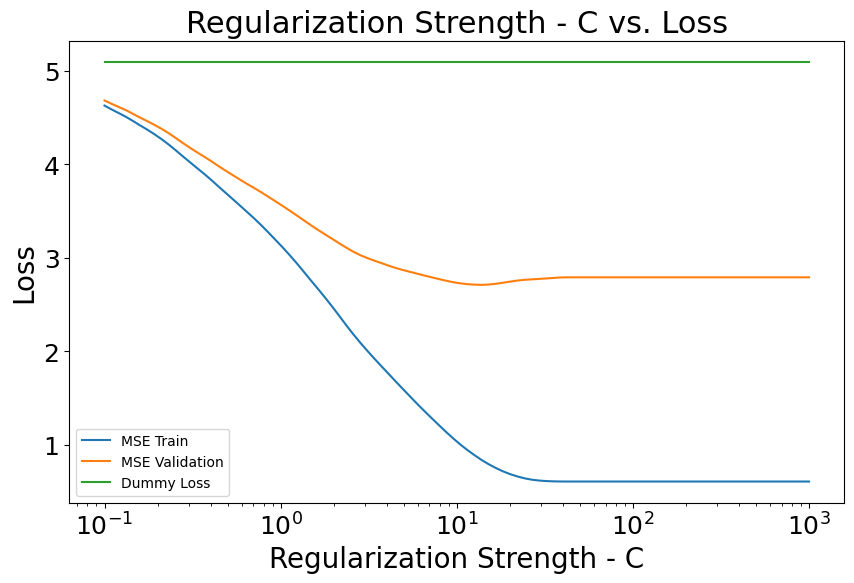

Best Regularization Strength: 13.848863713938732
Best Train: 0.6068161338554088
Best loss: 2.711045445997163


Pipeline(steps=[('regressor',
                 SVR(C=13.848863713938732, epsilon=1,
                     kernel=<function laplacian_kernel at 0x000001C698C81EE0>,
                     tol=1e-05))])

In [43]:
# Part 4 Q17
import sklearn
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
import matplotlib.pyplot as plt

X_train = normalized_train_set.drop(columns='contamination_level')
y_train = normalized_train_set['contamination_level']

# Define the range of regularization strengths to try
Cs = logspace(-1, 3, 100)

# Initialize lists to store the validation errors
val_errors = []

train_losses_SVR = {}
val_losses_SVR = {}

# Perform k-fold cross-validation for each alpha value
for C in Cs:
    poly_reg = Pipeline([(('regressor', SVR(kernel=sklearn.metrics.pairwise.laplacian_kernel, tol=1e-5, C=C, epsilon=1)))])
    cv_results = cross_validate(poly_reg, X_train, y_train, scoring={'huber_loss': huber_loss_scorer, 'mse': 'neg_mean_squared_error'}, cv=5, return_train_score=True)
    train_losses_SVR[C] = -cv_results['train_mse'].mean()
    val_losses_SVR[C] = -cv_results['test_mse'].mean()


# Plot the learning rate vs. mean squared error
plt.figure(figsize=(10, 6))
plt.plot(list(val_losses_SVR.keys()), list(train_losses_SVR.values()), label='MSE Train')
plt.plot(list(val_losses_SVR.keys()), list(val_losses_SVR.values()), label='MSE Validation')
plt.plot(list(val_losses_SVR.keys()), [mean_mse]*len(val_losses_SVR.keys()), label='Dummy Loss')
plt.xscale('log')
plt.xlabel('Regularization Strength - C')
plt.ylabel('Loss')
plt.title('Regularization Strength - C vs. Loss')
plt.legend()
plt.show()

print(f"Best Regularization Strength: {min(val_losses_SVR, key=val_losses_SVR.get)}")
print(f"Best Train: {train_losses_SVR[min(train_losses_SVR, key=train_losses_SVR.get)]}")
print(f"Best loss: {val_losses_SVR[min(val_losses_SVR, key=val_losses_SVR.get)]}")

X_train = normalized_train_set.drop(columns='contamination_level')
y_train = normalized_train_set['contamination_level']
poly_reg = Pipeline([(('regressor', SVR(kernel=sklearn.metrics.pairwise.laplacian_kernel, tol=1e-5, C=min(val_losses_SVR, key=val_losses_SVR.get), epsilon=1)))])
poly_reg.fit(X_train, y_train)

c:\Users\t-amuslih\OneDrive - Technion\Sem 7\ML\Major HW3\plot3d.py:28: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


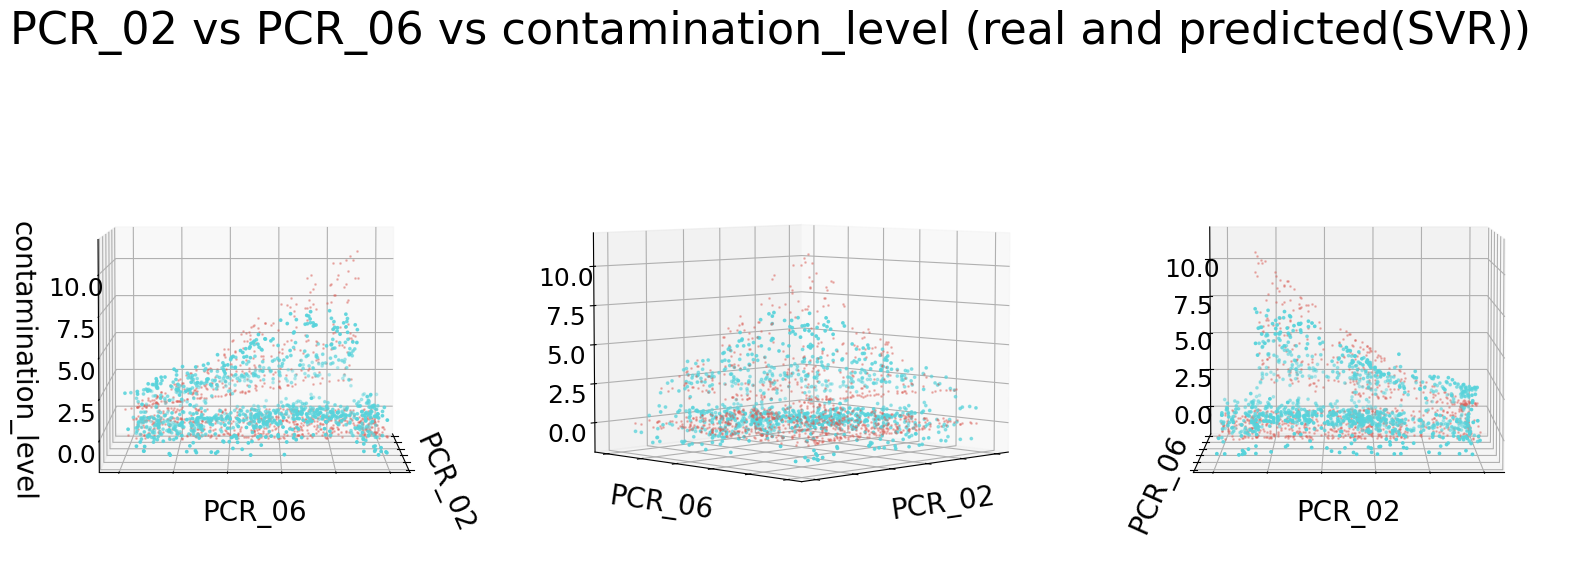

In [41]:
# Part 4 Q18
from plot3d import plot3d

X_train = normalized_train_set.drop(columns='contamination_level')
y_train = normalized_train_set['contamination_level']
# Plotting the predicted values
predicted_values = poly_reg.predict(X_train)

plot3d(normalized_train_set, "PCR_02", "PCR_06", "contamination_level", title='PCR_02 vs PCR_06 vs contamination_level (real and predicted(SVR))', predictions=predicted_values)


In [42]:
from sklearn.metrics import mean_squared_error

X_test = normalized_test_set.drop(columns='contamination_level')
y_test = normalized_test_set['contamination_level']
# Evaluate dummy_regressor
dummy_pred = dummy_regressor.predict(X_test)
dummy_mse = mean_squared_error(y_test, dummy_pred)
print("Dummy Regressor MSE:", dummy_mse)

# Evaluate huberRegressor
huber_pred = huberRegressor.predict(X_test)
huber_mse = mean_squared_error(y_test, huber_pred)
print("Huber Regressor MSE:", huber_mse)

# Evaluate ridge_regressor
ridge_pred = ridge_regressor.predict(X_test)
ridge_mse = mean_squared_error(y_test, ridge_pred)
print("Ridge Regressor MSE:", ridge_mse)

# Evaluate poly_reg
poly_pred = poly_reg.predict(X_test)
poly_mse = mean_squared_error(y_test, poly_pred)
print("Polynomial Regressor MSE:", poly_mse)


Dummy Regressor MSE: 5.890087121365286
Huber Regressor MSE: 4.501020627242895
Ridge Regressor MSE: 4.364301864514823
Polynomial Regressor MSE: 2.6114838339785185
